In [1]:
import pickle
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
dct_result = dict()

In [3]:
with open("OpenAI_same_question_response.pkl", "rb") as f:
    OpenAI_same_question_response = pickle.load(f)

with open("Grok_same_question_response.pkl", "rb") as f:
    Grok_same_question_response = pickle.load(f)

with open("Gemini_same_question_response.pkl", "rb") as f:
    Gemini_same_question_response = pickle.load(f)

with open("Llama_same_question_response.pkl", "rb") as f:
    Llama_same_question_response = pickle.load(f)

with open("Opentarget_same_question_response.pkl", "rb") as f:
    Opentarget_same_question_response = pickle.load(f)

with open("Biochatter_same_question_response.pkl", "rb") as f:
    Biochatter_same_question_response = pickle.load(f)

In [4]:
for model in ['llama-3.3-70b-versatile', 'gpt-5-nano', 'grok-4-1-fast-non-reasoning-latest', "gemini-2.5-flash-lite", "OpenTarget", "BioChatter"]:

    
    if model=="llama-3.3-70b-versatile":
        dct_result[model] = Llama_same_question_response[model]

    if model=="gpt-5-nano":
        dct_result[model] = OpenAI_same_question_response[model]

    if model=='grok-4-1-fast-non-reasoning-latest':
        dct_result[model] = Grok_same_question_response[model]

    if model=="gemini-2.5-flash-lite":
        dct_result[model] = Gemini_same_question_response[model]

    if model=="OpenTarget":
        dct_result[model] = Opentarget_same_question_response[model]

    if model=="BioChatter":
        dct_result[model] = Biochatter_same_question_response[model]


In [48]:
q = "Which drugs are associated with the BTK gene?"

In [49]:
# df_jaccard

In [50]:
df_jaccard[df_jaccard["query"]==q]

,model,query,jaccard
77,llama-3.3-70b-versatile,Which drugs are associated with the BTK gene?,0.090909
157,gpt-5-nano,Which drugs are associated with the BTK gene?,0.000000
236,grok-4-1-fast-non-reasoning-latest,Which drugs are associated with the BTK gene?,0.000000
316,gemini-2.5-flash-lite,Which drugs are associated with the BTK gene?,0.363636
395,OpenTarget,Which drugs are associated with the BTK gene?,1.000000
475,BioChatter,Which drugs are associated with the BTK gene?,0.000000


In [51]:
Biochatter_same_question_response["BioChatter"][q][1]

{'rows': 3,
 'latency': 21.301309971138835,
 'dataframe':        drug_name target_name gene_name mechanism_of_action approval_status
 0      Ibrutinib         BTK       BTK       BTK inhibitor        Approved
 1  Acalabrutinib         BTK       BTK       BTK inhibitor        Approved
 2   Zanubrutinib         BTK       BTK       BTK inhibitor        Approved}

In [55]:
# Biochatter_same_question_response["BioChatter"][q][2]

In [56]:
# Biochatter_same_question_response["BioChatter"][q][3]

In [57]:
# Biochatter_same_question_response["BioChatter"][q][4]

In [58]:
# Biochatter_same_question_response["BioChatter"][q][5]

In [5]:
Opentarget_same_question_response.keys()

dict_keys(['OpenTarget'])

In [6]:
# Gemini_same_question_response

In [7]:
# Opentarget_same_question_response

In [8]:
Opentarget_same_question_response.keys()

dict_keys(['OpenTarget'])

In [9]:
dct_result.keys()

dict_keys(['llama-3.3-70b-versatile', 'gpt-5-nano', 'grok-4-1-fast-non-reasoning-latest', 'gemini-2.5-flash-lite', 'OpenTarget', 'BioChatter'])

In [59]:
dct_result

{'llama-3.3-70b-versatile': {'Which diseases are associated with BRAF?': {1: {'rows': 4,
    'latency': 0.3896717019379139,
    'dataframe':   gene_name         disease_name
    0      BRAF             Melanoma
    1      BRAF    Colorectal Cancer
    2      BRAF       Thyroid Cancer
    3      BRAF  Hairy Cell Leukemia},
   2: {'rows': 3,
    'latency': 0.38092178106307983,
    'dataframe':         disease_name gene_name
    0           Melanoma      BRAF
    1  Colorectal cancer      BRAF
    2     Thyroid cancer      BRAF},
   3: {'rows': 4,
    'latency': 0.38182058557868004,
    'dataframe':           disease_name gene_name
    0    Colorectal cancer      BRAF
    1             Melanoma      BRAF
    2       Thyroid cancer      BRAF
    3  Hairy cell leukemia      BRAF},
   4: {'rows': 6,
    'latency': 0.4287004675716162,
    'dataframe':   gene_name                   disease_name
    0      BRAF            Hairy Cell Leukemia
    1      BRAF              Colorectal Cancer
    2 

In [11]:
records = []

for model, queries in dct_result.items():           # model level
    for query, runs in queries.items():             # query level
        for run_id, payload in runs.items():    
            print

In [12]:
records = []

for model, queries in dct_result.items():           # model level
    for query, runs in queries.items():             # query level
        for run_id, payload in runs.items():        # run level
            records.append({
                "model": model,
                "query": query,
                "run": int(run_id),
                "rows": int(payload.get("rows", 0)),
                "latency": payload.get("latency", 0)
            })

df_long = pd.DataFrame(records)


In [13]:
df_long[df_long["model"]=="OpenTarget"]["rows"].mean()

252.21628498727736

In [38]:
df_jaccard

,model,query,jaccard
0,llama-3.3-70b-versatile,Which diseases are associated with BRAF?,0.500000
1,llama-3.3-70b-versatile,List genes linked to amyotrophic lateral scler...,0.000000
2,llama-3.3-70b-versatile,Which diseases are associated with CDK4?,0.400000
3,llama-3.3-70b-versatile,Which pathways are associated with the JAK2 gene?,0.125000
4,llama-3.3-70b-versatile,Which drugs are used for treating rheumatoid a...,0.538462
...,...,...,...
473,BioChatter,Which drugs are associated with the CD19 gene?,0.000000
474,BioChatter,Which drugs are associated with the CTLA4 gene?,0.000000
475,BioChatter,Which drugs are associated with the BTK gene?,0.000000
476,BioChatter,Which drugs are associated with the SYK gene?,0.000000


In [37]:
df_long[df_long["model"]=="BioChatter"]

,model,query,run,rows,latency
1984,BioChatter,Which diseases are associated with BRAF?,1,7,23.869109
1985,BioChatter,Which diseases are associated with BRAF?,2,6,17.251174
1986,BioChatter,Which diseases are associated with BRAF?,3,6,15.747612
1987,BioChatter,Which diseases are associated with BRAF?,4,9,20.545786
1988,BioChatter,Which diseases are associated with BRAF?,5,7,16.844679
...,...,...,...,...,...
2379,BioChatter,Which pathways are associated with TP53?,1,4,16.268044
2380,BioChatter,Which pathways are associated with TP53?,2,3,16.286737
2381,BioChatter,Which pathways are associated with TP53?,3,3,21.233554
2382,BioChatter,Which pathways are associated with TP53?,4,4,14.743730


In [14]:

# df_long already exists with columns:
# ['model', 'query', 'run', 'rows']

heat_df_rows = (
    df_long
    .groupby(["model", "run"])["rows"]
    .median()          # robust to explosions
    .unstack(fill_value=0)
)


heat_df_latency = (
    df_long
    .groupby(["model", "run"])["latency"]
    .median()          # robust to explosions
    .unstack(fill_value=0)
)


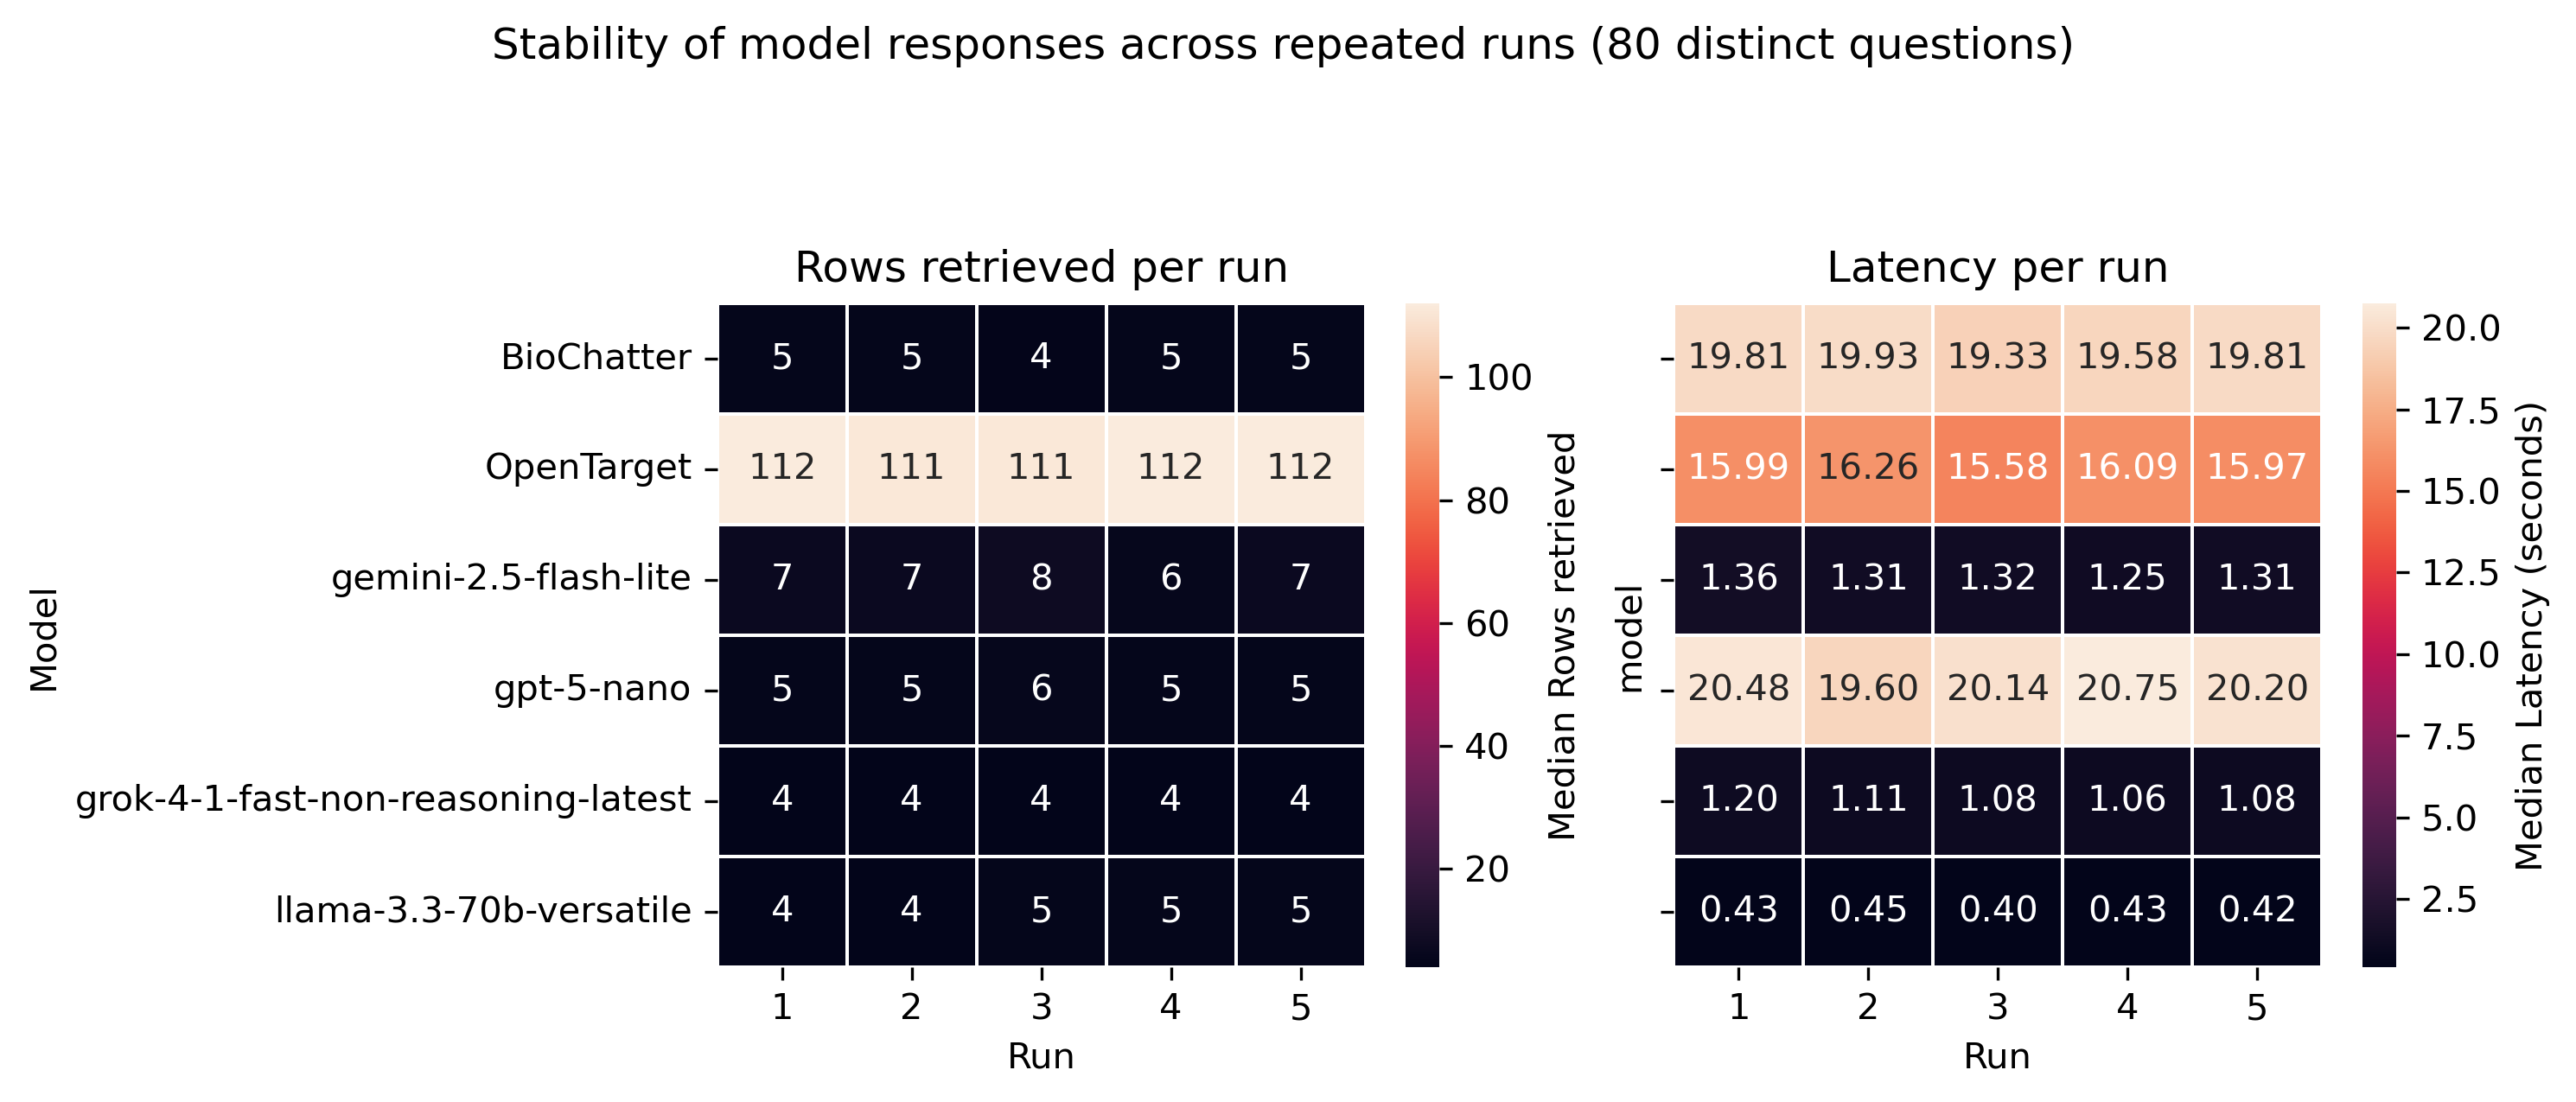

In [15]:
fig, ax = plt.subplots(
    1, 2,
    figsize=(10, 4),
    dpi=300,
    sharey=True
)

# -----------------------------
# Heatmap 1: Row count
# -----------------------------
sns.heatmap(
    heat_df_rows,
    annot=True,
    fmt=".0f",
    linewidths=0.5,
    annot_kws={"size": 10},
    cbar_kws={"label": "Median Rows retrieved"},
    ax=ax[0]
)

ax[0].set_title("Rows retrieved per run")
ax[0].set_xlabel("Run")
ax[0].set_ylabel("Model")

# -----------------------------
# Heatmap 2: Latency
# -----------------------------
sns.heatmap(
    heat_df_latency,
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    annot_kws={"size": 10},
    cbar_kws={"label": "Median Latency (seconds)"},
    ax=ax[1]
)

ax[1].set_title("Latency per run")
ax[1].set_xlabel("Run")

# -----------------------------
# Suptitle
# -----------------------------
fig.suptitle(
    "Stability of model responses across repeated runs (80 distinct questions)",
    fontsize=12,
    y=1.05
)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


In [23]:
# from io import StringIO
# import pandas as pd

# dct_jaccard = {}

# for model, queries in dct_result.items():
#     dct_jaccard[model] = {}

#     print(f"\nWorking for model: {model}")

#     for question, runs in queries.items():
#         print(question)
#         print(runs)
#         break
#     break

In [24]:
import pandas as pd

dct_jaccard = {}

for model, queries in dct_result.items():
    dct_jaccard[model] = {}
    print(f"\nWorking for model: {model}")

    for question, runs in queries.items():
        run_sets = []

        for run_id, payload in runs.items():
            df = payload.get("dataframe")

            if not isinstance(df, pd.DataFrame) or df.empty:
                continue

            try:
                row_set = set()

                for row in df.itertuples(index=False, name=None):
                    cleaned = [
                        str(v).strip().lower()
                        for v in row
                        if v is not None and not pd.isna(v)
                    ]

                    if cleaned:
                        row_set.add(tuple(sorted(cleaned)))

                if row_set:
                    run_sets.append(row_set)

            except Exception as e:
                print(f"  ⚠️ Run {run_id} skipped: {e}")

        if len(run_sets) < 2:
            print(f"  ❌ Not enough valid runs for '{question}'")
            dct_jaccard[model][question] = None
            continue

        intersection = set.intersection(*run_sets)
        union = set.union(*run_sets)

        jaccard = len(intersection) / len(union) if union else 0.0
        dct_jaccard[model][question] = jaccard

        print(f"  ✅ Jaccard for '{question}': {jaccard:.3f}")



Working for model: llama-3.3-70b-versatile
  ✅ Jaccard for 'Which diseases are associated with BRAF?': 0.500
  ✅ Jaccard for 'List genes linked to amyotrophic lateral sclerosis.': 0.000
  ✅ Jaccard for 'Which diseases are associated with CDK4?': 0.400
  ✅ Jaccard for 'Which pathways are associated with the JAK2 gene?': 0.125
  ✅ Jaccard for 'Which drugs are used for treating rheumatoid arthritis?': 0.538
  ✅ Jaccard for 'What are the targets and mechanisms for dulaglutide?': 0.000
  ✅ Jaccard for 'Provide target names for ovarian cancer?': 0.000
  ✅ Jaccard for 'What are the known targets of regorafenib?': 0.000
  ✅ Jaccard for 'Which pathways are associated with the STAT3 gene?': 0.222
  ✅ Jaccard for 'Genes linked to fever.': 0.000
  ✅ Jaccard for 'List all drugs that target EGFR?': 0.000
  ✅ Jaccard for 'Show drugs that inhibit the FGFR2 gene?': 0.000
  ✅ Jaccard for 'What diseases are treated with bevacizumab?': 0.000
  ✅ Jaccard for 'List treatments for plaque psoriasis and their

In [25]:
import pandas as pd

records = []

for model, qdict in dct_jaccard.items():
    for question, jac in qdict.items():
        if jac is None:
            continue
        records.append({
            "model": model,
            "query": question,
            "jaccard": jac
        })

df_jaccard = pd.DataFrame(records)


In [28]:
df_jaccard

,model,query,jaccard
0,llama-3.3-70b-versatile,Which diseases are associated with BRAF?,0.500000
1,llama-3.3-70b-versatile,List genes linked to amyotrophic lateral scler...,0.000000
2,llama-3.3-70b-versatile,Which diseases are associated with CDK4?,0.400000
3,llama-3.3-70b-versatile,Which pathways are associated with the JAK2 gene?,0.125000
4,llama-3.3-70b-versatile,Which drugs are used for treating rheumatoid a...,0.538462
...,...,...,...
473,BioChatter,Which drugs are associated with the CD19 gene?,0.000000
474,BioChatter,Which drugs are associated with the CTLA4 gene?,0.000000
475,BioChatter,Which drugs are associated with the BTK gene?,0.000000
476,BioChatter,Which drugs are associated with the SYK gene?,0.000000


In [20]:
df_jaccard[df_jaccard["model"]=="OpenTarget"]["jaccard"].mean()

1.0

/tmp/ipykernel_3568491/3055915022.py:38: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(


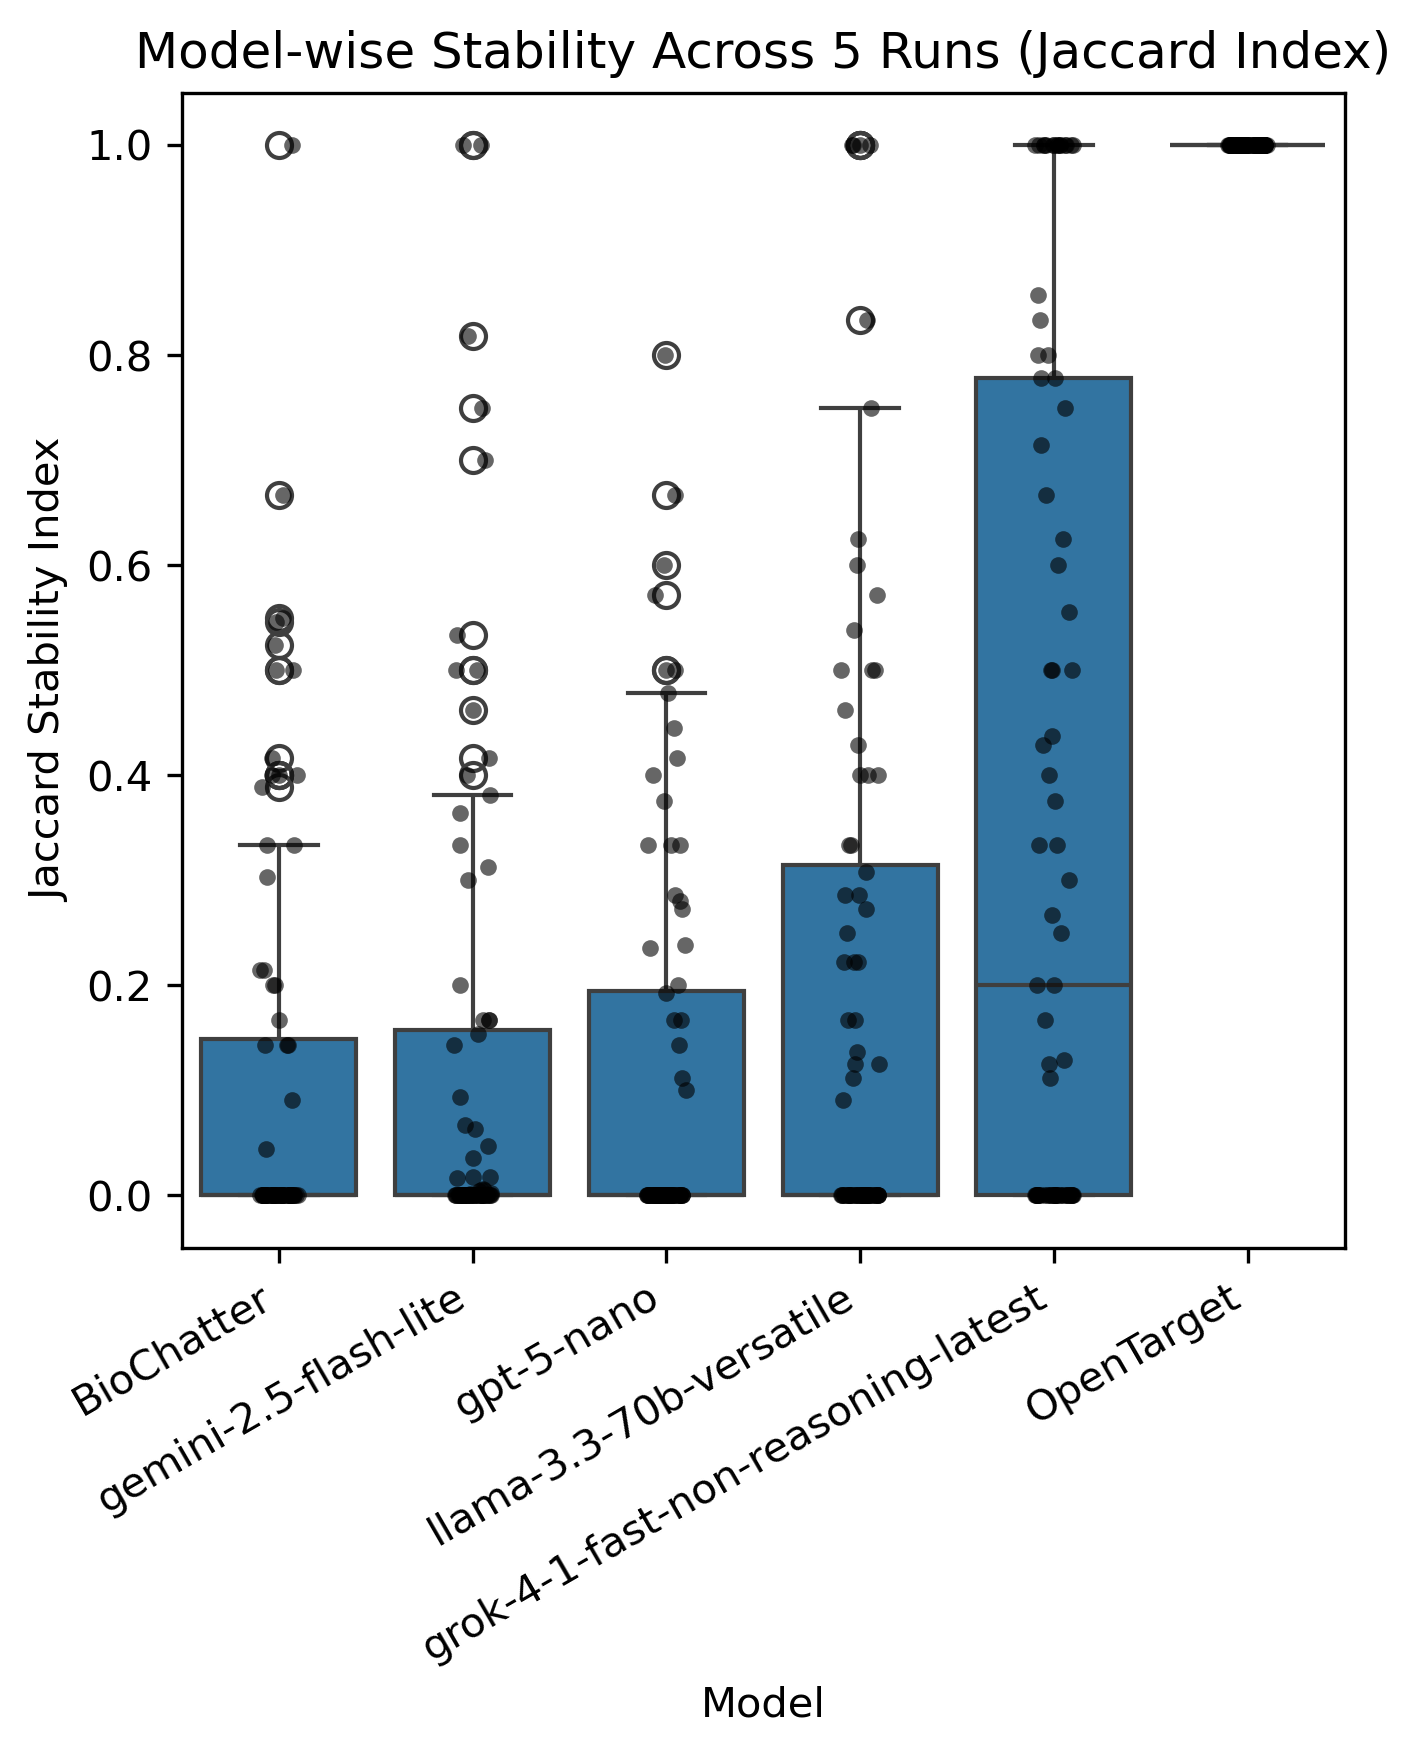

In [27]:
order = (
    df_jaccard
    .groupby("model")["jaccard"]
    .median()
    .sort_values(ascending=True)
    .index
)
import seaborn as sns
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(5, 5), dpi = 300)

sns.boxplot(
    data=df_jaccard,
    x="model",
    y="jaccard",
    order=order,
    showfliers=True,
    ax=ax
)

sns.stripplot(
    data=df_jaccard,
    x="model",
    y="jaccard",
    order=order,
    color="black",
    alpha=0.6,
    jitter=True,
    size=4,
    ax=ax
)

ax.set_ylabel("Jaccard Stability Index")
ax.set_xlabel("Model")
ax.set_title("Model-wise Stability Across 5 Runs (Jaccard Index)")

ax.set_xticklabels(
    ax.get_xticklabels(),
    rotation=30,
    ha="right"
)

# plt.tight_layout()
plt.show()


In [22]:
aaaa

NameError: name 'aaaa' is not defined

In [ ]:
from biochatter.llm_connect import GptConversation
import os

In [ ]:
prompt_md = "response as per user request"

In [ ]:
model = "gpt-5-nano"

conversation = GptConversation(
            model_name=model,
            prompts={}
        )

conversation.append_system_message(prompt_md)
success = conversation.set_api_key(os.getenv("OPENAI_API_KEY"), user="my_user")

In [ ]:
import biochatter_utility


In [ ]:
question = "What is drug for tb?"
a = await biochatter_utility.return_biochatter_answer(question)

In [ ]:
a

In [ ]:


answer, token_usage, correction = conversation.query(
    f"""Question: {question}
"""
)

In [ ]:
answer

In [ ]:
aa

In [ ]:
# Llama_same_question_response

In [ ]:
# dct_result = dict()
# dct_result["gpt-5-nano"] = OpenAI_same_question_response

In [ ]:
dct_result = Llama_same_question_response

In [ ]:
# OpenAI_same_question_response

In [ ]:
import pandas as pd

dct_jaccard = {}

for model in dct_result.keys():
    dct_jaccard[model] = {}
    print(f"\nWorking for model: {model}")

    for question_key, runs_dict in dct_result[model].items():
        tmp_result = {}

        for run_number, run_payload in runs_dict.items():
            try:
                df = run_payload.get("dataframe")

                if not isinstance(df, pd.DataFrame) or df.empty:
                    raise ValueError("Invalid or empty DataFrame")

                # -----------------------------
                # Convert rows ? canonical tuples
                # -----------------------------
                s = set()
                for row in df.itertuples(index=False, name=None):
                    clean_row = tuple(
                        str(v) for v in row
                        if v is not None and not pd.isna(v)
                    )
                    if clean_row:
                        s.add(clean_row)

                tmp_result[run_number] = s

            except Exception as e:
                print(
                    f"Error processing run {run_number} "
                    f"for question '{question_key}': {e}"
                )
                continue

        valid_runs = len(tmp_result)
        expected_runs = len(runs_dict)

        # -----------------------------
        # Sanity checks
        # -----------------------------
        if valid_runs < 2:
            print(
                f"Not enough valid runs for '{question_key}' "
                f"({valid_runs}/{expected_runs}). Skipping Jaccard."
            )
            continue

        if valid_runs < expected_runs:
            print(
                f"Warning: partial runs valid for '{question_key}': "
                f"{valid_runs}/{expected_runs}"
            )

        # -----------------------------
        # Jaccard computation
        # -----------------------------
        sets = list(tmp_result.values())
        intersection = set.intersection(*sets)
        union = set.union(*sets)

        if not union:
            print(f"Empty union for '{question_key}', skipping Jaccard.")
            continue

        jaccard_index = len(intersection) / len(union)

        dct_jaccard[model][question_key] = jaccard_index
        print(
            f"Jaccard index for '{question_key}': "
            f"{jaccard_index:.4f}"
        )


In [60]:
import requests
import pandas as pd
from collections import Counter

def search_opentargets(search_term):
    """
    Search OpenTargets for a given term and identify if it's a drug, disease, or target.
    
    Args:
        search_term (str): The term to search for
        
    Returns:
        dict: {'entity_type': 'drug'/'disease'/'target', 'id': 'xxx', 'name': 'xxx'} or None if not found
    """
    url = "https://api.platform.opentargets.org/api/v4/graphql"
    
    query = """
    query SearchQuery($queryString: String!) {
      search(queryString: $queryString, page: {size: 5, index: 0}) {
        hits {
          id
          entity
          name
          score
        }
      }
    }
    """
    
    variables = {"queryString": search_term}
    
    try:
        response = requests.post(
            url,
            json={"query": query, "variables": variables},
            headers={"Content-Type": "application/json"},
            timeout=10
        )
        
        if response.status_code != 200:
            return None
        
        data = response.json()
        
        if "errors" in data:
            return None
        
        if "data" in data and "search" in data["data"] and data["data"]["search"]:
            hits = data["data"]["search"]["hits"]
            
            if hits:
                top_hit = hits[0]
                entity_type = top_hit.get("entity")
                
                if entity_type in ["drug", "disease", "target"]:
                    return {
                        "entity_type": entity_type,
                        "id": top_hit.get("id"),
                        "name": top_hit.get("name")
                    }
        
        return None
        
    except Exception as e:
        return None


def detect_column_type(df, column_name, sample_size=2):
    """
    Detect if a column contains drugs, diseases, or targets by sampling entries.
    
   
        
    Returns:
        str: Detected entity type ('drug', 'disease', 'target', or 'unknown')
    """
    # Get non-null values from the column
    non_null_values = df[column_name].dropna().astype(str).unique()
    
    if len(non_null_values) == 0:
        return 'unknown'
    
    # Sample up to sample_size entries
    sample_values = non_null_values[:min(sample_size, len(non_null_values))]
    
    entity_types = []
    for value in sample_values:
        result = search_opentargets(value)
        if result:
            entity_types.append(result['entity_type'])
    
    if not entity_types:
        return 'unknown'
    
    # Return the most common entity type
    most_common = Counter(entity_types).most_common(1)[0][0]
    return most_common


def process_dataframe(df, sample_size=2):
    """
    Process dataframe to identify column types and add OpenTargets IDs.
    
   
        
    Returns:
        pd.DataFrame: New dataframe with renamed columns and added ID columns
    """
    # Create a copy to avoid modifying original
    result_df = df.copy()
    
    # Dictionary to store column type information
    column_info = {}
    
    print("Detecting column types...")
    for col in df.columns:
        entity_type = detect_column_type(df, col, sample_size)
        column_info[col] = entity_type
        print(f"  {col}: {entity_type.upper()}")
    
    print("\nProcessing dataframe...")
    
    # Rename columns and add ID columns
    new_columns = {}
    id_columns = {}
    
    for col in df.columns:
        entity_type = column_info[col]
        
        if entity_type != 'unknown':
            # Rename column to entity type
            new_col_name = entity_type
            
            # If column name already exists, add suffix
            suffix = 1
            while new_col_name in new_columns.values():
                new_col_name = f"{entity_type}_{suffix}"
                suffix += 1
            
            new_columns[col] = new_col_name
            
            # Create ID column
            id_col_name = f"{new_col_name}_id"
            id_data = []
            
            for value in df[col]:
                if pd.isna(value):
                    id_data.append(None)
                else:
                    result = search_opentargets(str(value))
                    id_data.append(result['id'] if result else None)
            
            id_columns[id_col_name] = id_data
        else:
            new_columns[col] = col  # Keep original name if unknown
    
    # Rename columns
    result_df.rename(columns=new_columns, inplace=True)
    
    # Add ID columns
    for id_col_name, id_data in id_columns.items():
        result_df[id_col_name] = id_data
    
    return result_df

In [66]:
help(process_dataframe)

Help on function process_dataframe in module __main__:

process_dataframe(df, sample_size=2)
    Process dataframe to identify column types and add OpenTargets IDs.
    
    
        
    Returns:
        pd.DataFrame: New dataframe with renamed columns and added ID columns



In [68]:
process_dataframe(df= dct_result['llama-3.3-70b-versatile']['Which diseases are associated with BRAF?'][1]['dataframe'])

Detecting column types...
  gene_name: TARGET
  disease_name: DISEASE

Processing dataframe...


,target,disease,target_id,disease_id
0,BRAF,Melanoma,ENSG00000157764,EFO_0000756
1,BRAF,Colorectal Cancer,ENSG00000157764,MONDO_0005575
2,BRAF,Thyroid Cancer,ENSG00000157764,MONDO_0002108
3,BRAF,Hairy Cell Leukemia,ENSG00000157764,EFO_1000956


In [65]:
dct_result['llama-3.3-70b-versatile']['Which diseases are associated with BRAF?'][1]['dataframe']

,gene_name,disease_name
0,BRAF,Melanoma
1,BRAF,Colorectal Cancer
2,BRAF,Thyroid Cancer
3,BRAF,Hairy Cell Leukemia
